# Module analysis with SDA

In [5]:
%run ~/analysisLibraries

In [6]:
%matplotlib inline

In [7]:
%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


## Read data containing all necessary scores and relevant genes calculated in the previous notebook

In [9]:
adata = sc.read('../write/SDA_object.h5ad')

In [32]:
#read component number from the pipeline
#from os import environ #library that connects to the UNIX environment
#comp = str(environ['COMPONENT'])

## Open SDA matrices

In [10]:
A = pd.read_csv('SDA/ALLDATA_scaled_onematrix_data/it2000/A', sep=' ', header=None)
X = pd.read_csv('SDA/ALLDATA_scaled_onematrix_data/it2000/X1', sep=' ', header=None)
S = pd.read_csv('SDA/ALLDATA_scaled_onematrix_data/it2000/S1', sep=' ', header=None)

$A$ contains the score of each cell in the components. This score can be used as a "soft clustering" once it is normalized. We will try to do that in the notebook that follows this one. 

In [11]:
A.shape

(10522, 15)

In [12]:
A.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
0,0.823578,-0.150856,-0.232868,0.978262,0.941127,0.149279,-0.895419,0.488612,-0.142367,-0.650650,0.047764,-1.797530,-0.291950,-0.285636,-0.051455
1,0.412280,-0.381873,-0.153474,-0.479830,-0.742368,0.240343,0.763881,0.456313,0.191713,-0.217358,-0.112295,0.387332,-0.520114,-0.011430,-1.238040
2,-0.116371,-0.155019,0.157816,-1.017400,0.526689,0.398200,-0.821739,0.538557,-0.649574,-0.507511,0.035280,0.748228,2.085870,0.128419,0.152133
3,-0.191306,-0.301525,2.223640,-0.386508,-0.229589,0.379063,-0.091058,0.557750,-0.022447,1.450060,-0.230327,0.628984,-1.147190,-0.250618,1.056060
4,0.662584,-0.424341,-0.118680,-0.645929,-0.383942,0.136237,0.043829,-0.638192,-0.008545,-0.352948,-0.009485,0.573066,-0.846059,-0.054262,-0.036807


In [13]:
#B

$X$ contains the loading of each gene in each component according to the spike-and-slab prior. The sign of the loading has to be considered together with the sign of the cell score to see if the resulting sign is positive (significant expression of gene) or negative (significant underexpression of gene)

In [14]:
X.columns = adata.var_names

In [15]:
X.shape

(15, 14409)

In [16]:
X.head()

index,A1BG,A2M,A2ML1,AAAS,AACS,AADAT,AAED1,AAGAB,AAK1,AAMDC,...,ZUP1,ZW10,ZWILCH,ZWINT,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3
0,-0.001271,0.002861,-0.040488,0.000411,0.000119,-0.000019,-0.109392,-0.035660,-0.000174,-0.101341,...,-0.000968,-0.000006,0.000177,-0.000106,-0.000019,-0.000268,0.000096,-0.000114,0.000470,-0.000680
1,0.003783,0.113529,0.038002,-0.000122,-0.000143,0.069189,-0.000034,-0.073289,-0.079646,-0.000039,...,0.000427,-0.014813,-0.007363,-0.001254,0.140359,-0.000068,-0.032127,-0.037927,-0.000106,-0.035350
2,-0.000145,-0.001594,0.000110,-0.000199,-0.000277,0.000139,-0.000031,0.084301,0.000007,0.001438,...,-0.003909,0.056287,0.000106,0.006375,0.000083,0.000129,0.032034,-0.000221,-0.004367,-0.030715
3,-0.000040,0.038087,-0.085117,-0.000052,-0.000249,-0.000071,0.000782,0.012083,0.006578,-0.127971,...,-0.000163,-0.000272,-0.000206,-0.043670,0.000392,0.000030,-0.000049,0.000167,-0.059943,-0.000244
4,-0.000249,-0.000555,0.000264,0.000464,-0.030960,0.005369,-0.000225,-0.042875,0.043919,-0.000871,...,-0.000334,-0.000312,0.071707,-0.001734,-0.000366,-0.000091,0.000099,0.000568,0.062290,-0.001858


S contains a likelihood telling you if genes you consider relevant, are actually likely to be detected as such. In the Jung et al paper they check the likelihood with a >0.5 threshold. I consider this threshold here

In [17]:
S.columns = adata.var_names

In [18]:
S

index,A1BG,A2M,A2ML1,AAAS,AACS,AADAT,AAED1,AAGAB,AAK1,AAMDC,...,ZUP1,ZW10,ZWILCH,ZWINT,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3
0,0.078188,0.155646,0.997742,0.035922,0.023861,0.015585,1.000000,0.983141,0.023403,1.000000,...,0.070144,0.015213,0.023362,0.023742,0.016984,0.028280,0.018313,0.019365,0.040108,0.057046
1,0.189305,1.000000,0.992997,0.023497,0.024689,1.000000,0.017727,1.000000,1.000000,0.017762,...,0.038558,0.581133,0.337558,0.081067,1.000000,0.020168,0.960783,0.987858,0.020710,0.989050
2,0.032779,0.108874,0.030418,0.035292,0.039451,0.031912,0.028916,1.000000,0.025108,0.105273,...,0.217671,1.000000,0.029607,0.316419,0.028053,0.031087,0.972287,0.035780,0.238033,0.966304
3,0.028423,0.993554,1.000000,0.029598,0.036013,0.028322,0.070952,0.522284,0.337407,1.000000,...,0.032429,0.038836,0.035767,0.999469,0.044896,0.027565,0.027538,0.032935,1.000000,0.036117
4,0.040787,0.057839,0.040423,0.053309,0.949673,0.284368,0.039019,0.999562,0.999925,0.078843,...,0.044368,0.044417,1.000000,0.118201,0.049183,0.032406,0.031172,0.057993,1.000000,0.126923
5,0.999871,0.330913,0.301718,0.999993,0.999986,0.038890,1.000000,0.139284,0.154348,0.038598,...,0.952545,1.000000,0.422446,0.880407,0.204433,0.025579,0.989816,0.149344,1.000000,0.039358
6,0.999952,0.016096,1.000000,1.000000,0.059835,0.015360,1.000000,1.000000,1.000000,0.016420,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.013926,1.000000,1.000000
7,0.031876,0.025391,0.015575,0.790122,0.017553,1.000000,0.015086,1.000000,1.000000,0.999987,...,1.000000,1.000000,1.000000,0.999804,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
8,0.021435,0.039174,0.029079,1.000000,1.000000,0.039068,0.022977,0.018600,0.023973,0.018222,...,0.033300,1.000000,1.000000,1.000000,0.022330,0.016759,0.695845,0.066250,0.018911,0.017826
9,0.013399,0.999297,0.020455,0.010947,1.000000,0.009095,0.984685,1.000000,0.013555,0.950267,...,1.000000,1.000000,1.000000,1.000000,0.513398,0.010792,1.000000,0.013715,0.009930,1.000000


## Pseudotime ordering of positive and negative components
here you need to look by eye the plot notebooks and consider if: each positive and negative component has to be considered separately because does not show overlapping significant cells in pseudotimes (both), only positive component has enough significant cells (pos), only the negative component has significant cells (neg) or if the two components overlap pretty well (all). A bit of a shitty way of doing it, but the Jung et al has probably been done this way, where they looked at components one by one with some rough selection criteria. Also look if components express specific sets of genes. for example ribosomal genes or cell cycle genes. According to how you choose components, relevant cells and genes are being organized

In [19]:
adata.rename_categories('batch',['NUCLEI','CELL'])

In [43]:
#comps = [str(i) for i in range(X.shape[0])]
#good_comps = [i for i in comps if i not in ['13','43','46','44']]

In [20]:
compDict = dict()
compDict[0] = ['neg']
compDict[1] = ['pos']
compDict[2] = ['all']
compDict[3] = ['all']
compDict[4] = ['both'] #components are "opposite"
compDict[5] = ['neg'] #positive is a technical component of ribosomal genes
compDict[6] = ['pos']
compDict[7] = ['neg']
compDict[8] = ['pos']
compDict[9] = ['pos']
compDict[10] = ['neg']
compDict[11] = ['neg']
compDict[12] = ['pos']
compDict[13] = ['neg'] #stronger in cells than nuclei
compDict[14] = ['all']
#all=PN component both= P and N components separately
allComps = ['0N','1P','2PN','3PN','4P','4N','5N','6P','7N',
            '8P','9P','10N','11N','12P','13N','14PN']
counter = 0
for i in range(X.shape[0]):
    if compDict[i][0] == 'neg':
        print(allComps[counter])
        comp_new = np.array(adata.obs[f'sda_cell_relevant_C{i}'])
        comp_new[comp_new == 'POSITIVE'] = 'IRRELEVANT'
        comp_new[comp_new == 'NEGATIVE'] = 'RELEVANT'
        VARNAMES = np.asarray(adata[:,adata.var[f'sda_neg_low_C{i}']].var_names)
        VARNAMES = VARNAMES[ np.where( S.loc[int(i),VARNAMES]>.5 ) ]
        adata.var[f'sda_{allComps[counter]}'] = [i in VARNAMES for i in adata.var_names]
        adata.obs[f'sda_{allComps[counter]}'] = pd.Categorical(comp_new)
        counter += 1
    if compDict[i][0] == 'pos':
        print(allComps[counter])
        comp_new = np.array(adata.obs[f'sda_cell_relevant_C{i}'])
        comp_new[comp_new == 'POSITIVE'] = 'RELEVANT'
        comp_new[comp_new == 'NEGATIVE'] = 'IRRELEVANT'  
        adata.obs[f'sda_{allComps[counter]}'] = pd.Categorical(comp_new)
        VARNAMES = np.asarray(adata[:,adata.var[f'sda_pos_low_C{i}']].var_names)
        VARNAMES = VARNAMES[ np.where( S.loc[int(i),VARNAMES]>.5 ) ]
        adata.var[f'sda_{allComps[counter]}'] = [i in VARNAMES for i in adata.var_names]
        counter += 1
    if compDict[i][0] == 'all':
        x=allComps[counter]
        print(allComps[counter])
        comp_new = np.array(adata.obs[f'sda_cell_relevant_C{i}'])
        comp_new[comp_new == 'POSITIVE'] = 'RELEVANT'
        comp_new[comp_new == 'NEGATIVE'] = 'RELEVANT' 
        adata.obs[f'sda_{allComps[counter]}'] = pd.Categorical(comp_new)
        VARNAMES = np.asarray(adata[:,(adata.var[f'sda_neg_low_C{i}'])|(adata.var[f'sda_pos_low_C{i}'])].var_names)
        VARNAMES = VARNAMES[ np.where( S.loc[int(i),VARNAMES]>.5 ) ]
        adata.var[f'sda_{allComps[counter]}'] = [i in VARNAMES for i in adata.var_names]
        counter += 1
    if compDict[i][0] == 'both':
        x=allComps[counter]
        print(allComps[counter])
        comp_new = np.array(adata.obs[f'sda_cell_relevant_C{i}'])
        comp_new[comp_new == 'POSITIVE'] = 'RELEVANT'
        comp_new[comp_new == 'NEGATIVE'] = 'IRRELEVANT'  
        adata.obs[f'sda_{allComps[counter]}'] = pd.Categorical(comp_new)
        VARNAMES = np.asarray(adata[:,adata.var[f'sda_pos_low_C{i}']].var_names)
        VARNAMES = VARNAMES[ np.where( S.loc[int(i),VARNAMES]>.5 ) ]
        adata.var[f'sda_{allComps[counter]}'] = [i in VARNAMES for i in adata.var_names]
        counter += 1      
        comp_new = np.array(adata.obs[f'sda_cell_relevant_C{i}'])
        comp_new[comp_new == 'POSITIVE'] = 'IRRELEVANT'
        comp_new[comp_new == 'NEGATIVE'] = 'RELEVANT'
        VARNAMES = np.asarray(adata[:,adata.var[f'sda_neg_low_C{i}']].var_names)
        VARNAMES = VARNAMES[ np.where( S.loc[int(i),VARNAMES]>.5 ) ]
        adata.var[f'sda_{allComps[counter]}'] = [i in VARNAMES for i in adata.var_names]
        adata.obs[f'sda_{allComps[counter]}'] = pd.Categorical(comp_new)
        counter += 1
    if compDict[i][0] == 'none':
        x=allComps[counter]
        print(allComps[counter])
        comp_new = np.array(adata.obs[f'sda_cell_relevant_C{i}'])
        comp_new[comp_new == 'POSITIVE'] = 'IRRELEVANT'
        comp_new[comp_new == 'NEGATIVE'] = 'IRRELEVANT'  

0N
1P
2PN
3PN
4P
5N
6P
7N
8P
9P
10N
11N
12P
13N
14PN


In [45]:
adata

AnnData object with n_obs × n_vars = 10482 × 14409
    obs: 'batch', 'batch_dataset', 'branch_monocle', 'cluster', 'condition', 'doublet_scores', 'dpt_monocle', 'dpt_pseudotime', 'initial_size', 'initial_size_spliced', 'initial_size_unspliced', 'leiden', 'leiden_sub', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'n_counts', 'n_genes', 'n_genes_by_counts', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'pct_counts_in_top_50_genes', 'percent_mito', 'predicted_doublets', 'prop_spl', 'prop_unspl', 'recluster', 'scaled_CDR', 'total_counts', 'SDA_cellscore_C0', 'SDA_cellscore_C1', 'SDA_cellscore_C2', 'SDA_cellscore_C3', 'SDA_cellscore_C4', 'SDA_cellscore_C5', 'SDA_cellscore_C6', 'SDA_cellscore_C7', 'SDA_cellscore_C8', 'SDA_cellscore_C9', 'SDA_cellscore_C10', 'SDA_cellscore_C11', 'SDA_cellscore_C12', 'SDA_cellscore_C13', 'SDA_cellscore_C14', 'sda_cell_relevant_C0', 'sda_cell_relevant_C1', 'sda_cell_relevant_C2', 'sda_cell_relevant_C3', 'sda_ce

## Something with pseudotimes
here I made a table where I looked at average pseudotime and pseudotimes standard deviation in each component for the two different datasets

In [23]:
dfCellTime = pd.DataFrame(index=allComps, columns=['MEAN','SD'])
for i in allComps:
    time = adata[(adata.obs['condition']=='cells')&(adata.obs[f'sda_{i}']=='RELEVANT')].obs['dpt_cellalign']
    dfCellTime.loc[i,'MEAN'] = np.median(time)
    dfCellTime.loc[i,'SD'] = np.std(time)
    
dfNucleiTime = pd.DataFrame(index=allComps, columns=['MEAN','SD'])
for i in allComps:
    time = adata[(adata.obs['condition']!='cells')&(adata.obs[f'sda_{i}']=='RELEVANT')].obs['dpt_cellalign']
    dfNucleiTime.loc[i,'MEAN'] = np.median(time)
    dfNucleiTime.loc[i,'SD'] = np.std(time)

In [24]:
cell_idx = np.asarray( pd.Series.sort_values(dfCellTime['MEAN']).index )

In [25]:
cell_df = pd.DataFrame(columns=['dpt', 'component','cluster','dataset'])

In [26]:
cell_idx

array(['1P', '13N', '7N', '5N', '10N', '4P', '6P', '14PN', '2PN', '8P',
       '9P', '0N', '12P', '3PN', '4N', '11N'], dtype=object)

In [27]:
for i in cell_idx:
    df = pd.DataFrame(columns=['dpt', 'component','cluster', 'dataset'])
    df['dpt'] = adata[ adata.obs[f'sda_{i}']=='RELEVANT' ].obs['dpt_cellalign']
    df['component'] = [str(i) for n in adata[ adata.obs[f'sda_{i}']=='RELEVANT' ].obs['dpt_cellalign']]
    df['cluster'] = adata[ adata.obs[f'sda_{i}']=='RELEVANT' ].obs['recluster']
    df['dataset'] = adata[ adata.obs[f'sda_{i}']=='RELEVANT' ].obs['batch']
    cell_df = pd.concat([cell_df,df], axis=0)

In [28]:
cell_df

,dpt,component,cluster,dataset
AAAGAACGTCAACCTA-0-0,0.015917,1P,SSC,NUCLEI
AACGGGAAGGATCACG-0-0,0.123077,1P,SSC,NUCLEI
AAGACAAAGCTAATCC-0-0,0.099704,1P,SSC,NUCLEI
AAGGTAAAGTGGAAGA-0-0,0.031082,1P,SSC,NUCLEI
AAGTGAAAGCAGCACA-0-0,0.208321,1P,SSC,NUCLEI
...,...,...,...,...
TTTCACAAGTAGCCAG-1,0.826954,11N,E_SPT,CELL
TTTGATCGTTGTATGC-1,0.777501,11N,E_SPT,CELL
TTTGATCTCCACAGCG-1,0.891193,11N,E_SPT,CELL
TTTGGAGCAACTCGAT-1,0.906043,11N,E_SPT,CELL


## Module pseudotimes

Pseudotimes of each module found in SDA for cells and nuclei data

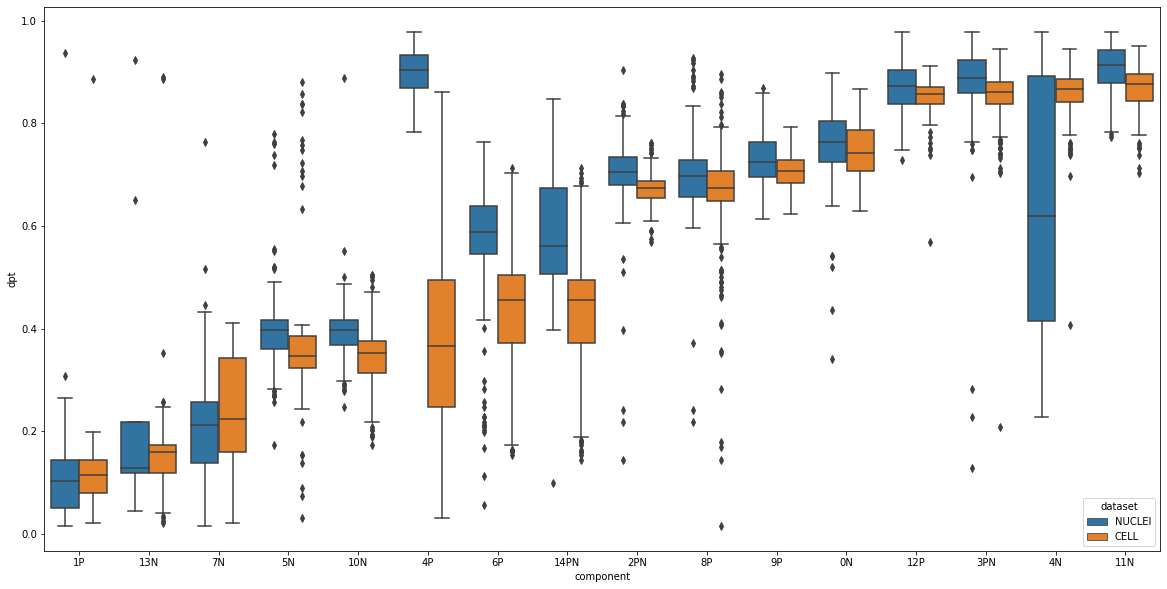

In [29]:
plt.rcParams['figure.figsize']=(20,10)
sns.boxplot(data=cell_df, y='dpt', x='component', order=cell_idx, hue='dataset')

In [30]:
pd.concat([dfCellTime,dfNucleiTime], 1)

,MEAN,SD,MEAN,SD
0N,0.742877,0.0541541,0.763996,0.0554533
1P,0.114808,0.101539,0.103842,0.0650391
2PN,0.6736,0.032965,0.704492,0.0568084
3PN,0.861544,0.0520032,0.888082,0.0570728
4P,0.367022,0.17545,0.902967,0.0428942
4N,0.866467,0.0450958,0.619202,0.26755
5N,0.347224,0.197983,0.396987,0.0696851
6P,0.456047,0.10193,0.589389,0.0834671
7N,0.223671,0.100274,0.212493,0.0900944
8P,0.6736,0.0909656,0.697092,0.104128


## Enrichment analysis
Here I tried some enrichment analysis for the genes in the various components. might be crap

In [31]:
geneDict = dict()
for i in allComps:
    genes = adata[:,adata.var[f'sda_{i}']].var_names
    geneDict[i] = np.unique(genes)
geneDict

{'0N': array(['AANAT', 'ABAT', 'ADGB', 'AGBL3', 'AGBL4', 'AIM2', 'ALS2CR12',
        'ANKFN1', 'ANKS1A', 'ANKUB1', 'ANO3', 'ARHGEF3', 'ARID1B', 'ARMH1',
        'ATG10', 'ATXN7L1', 'BTBD16', 'C10H10orf67', 'C12H12orf71',
        'C6H6orf118', 'C8H8orf89', 'C9H9orf135', 'CABCOCO1', 'CADM1',
        'CAPS2', 'CCDC138', 'CCDC146', 'CCDC148', 'CCDC151', 'CCDC170',
        'CCDC178', 'CCDC192', 'CCDC30', 'CCDC60', 'CCDC81', 'CDKL3',
        'CEP112', 'CEP83', 'CFAP157', 'CFAP221', 'CFAP299', 'CFAP43',
        'CFAP47', 'CFAP54', 'CFAP58', 'CFAP61', 'CFAP69', 'CFAP77',
        'CNBD1', 'DCDC2', 'DEUP1', 'DNAH14', 'DNAH6', 'DNAH7', 'DNAH9',
        'DOPEY1', 'DYNC2H1', 'EFCAB11', 'EFHB', 'ENOX1', 'ENTPD1',
        'ERICH6B', 'EXTL2', 'FAM189A1', 'FAM221B', 'FHAD1', 'FNDC3B',
        'FOXN3', 'FRMD5', 'FSIP1', 'GAS2', 'GOLGA6L2', 'GRM3', 'HEATR4',
        'HS2ST1', 'HYDIN', 'IQCA1', 'IQCH', 'JAKMIP2', 'KATNAL2', 'KCNT2',
        'KCNU1', 'KIAA0825', 'KIF6', 'LDLRAD4', 'LEKR1', 'LRGUK', 'LRRC2'

In [32]:
import gseapy as gp
names = gp.get_library_name()

## Enrichment terms for each module

Tables with enrichment terms for each module

In [35]:
import gseapy as gp
enr_cell = None
for C in allComps:
    if len(geneDict[C])>0:
        print(C)
        enr_cell = gp.enrichr(gene_list=np.ndarray.tolist(geneDict[C]),
                     gene_sets=['GO_Molecular_Function_2018', 
                                'GO_Biological_Process_2018', 
                                'KEGG_2019_Human',
                                'WikiPathways_2019_Human', 
                                'Human_Phenotype_Onthology',
                                'MGI_Mammalian_Phenotype_Level_4_2019',
                                'Chromosome_Location_hg19',
                                'Jensen_COMPARTMENTS',],
                     organism='Human', # don't forget to set organism to the one you desired! e.g. Yeast
                     description='enrichment',
                     outdir=f'./SDA/results_CELLS_sctransform_scaled_onematrix_data_15C/enrichr_{C}',
                     # no_plot=True,
                     cutoff=0.001
                    )
    if enr_cell:
        enr_cell_sorted = enr_cell.results.sort_values(by=['Adjusted P-value'], inplace=False)
        display(enr_cell_sorted.loc[ enr_cell_sorted['Adjusted P-value']<0.001 , 
                     ['Gene_set', 'Term', 'Overlap', 'Adjusted P-value', 'Genes', 'Combined Score', 'Odds Ratio'] ])
        enr_cell_sorted.loc[ enr_cell_sorted['Adjusted P-value']<0.001 , 
                     ['Gene_set', 'Term', 'Overlap', 'Adjusted P-value', 'Genes', 'Combined Score', 'Odds Ratio'] ].to_csv(
                     f'./SDA/results_CELLS_sctransform_scaled_onematrix_data_15C/enrichr_{C}/res.csv',
                     sep='\t', index=False)

0N


2020-09-30 13:47:02,092 Warning: No enrich terms using library KEGG_2019_Human when cutoff = 0.001
2020-09-30 13:47:04,624 Warning: No enrich terms using library WikiPathways_2019_Human when cutoff = 0.001
2020-09-30 13:47:10,057 Warning: No enrich terms using library Chromosome_Location_hg19 when cutoff = 0.001


,Gene_set,Term,Overlap,Adjusted P-value,Genes,Combined Score,Odds Ratio
1513,Jensen_COMPARTMENTS,Ciliary plasm,10/95,0.000002,SPAG16;DYNC2H1;SPAG17;DNAH7;DNAH6;HYDIN;DCDC2;...,292.734616,14.519056
1512,Jensen_COMPARTMENTS,Axoneme,10/95,0.000004,SPAG16;DYNC2H1;SPAG17;DNAH7;DNAH6;HYDIN;DCDC2;...,292.734616,14.519056
146,GO_Biological_Process_2018,cilium movement (GO:0003341),8/49,0.000011,CFAP61;SPAG17;DNAH7;LRRC6;DNAH9;WDR78;CFAP54;C...,448.872804,22.519353
1514,Jensen_COMPARTMENTS,Ciliary part,14/332,0.000108,DYNC2H1;SPAG16;SPAG17;PACRG;SPEF2;DNAH7;DNAH6;...,91.735759,5.816369
0,GO_Molecular_Function_2018,"ATP-dependent microtubule motor activity, minu...",5/17,0.000124,DYNC2H1;DNAH7;DNAH14;DNAH6;DNAH9,650.827172,40.567951
856,MGI_Mammalian_Phenotype_Level_4_2019,MP:0009838 abnormal sperm axoneme morphology,6/32,0.000178,SPAG16;LRGUK;SPEF2;KATNAL2;CFAP43;CFAP54,416.454527,25.862069
854,MGI_Mammalian_Phenotype_Level_4_2019,MP:0009239 short sperm flagellum,6/27,0.000180,LRGUK;SPEF2;CADM1;KATNAL2;CFAP43;CFAP54,526.956532,30.651341
855,MGI_Mammalian_Phenotype_Level_4_2019,MP:0011050 abnormal respiratory motile cilium ...,5/16,0.000201,SPAG17;ULK4;HYDIN;LRRC6;CFAP54,706.265430,43.103448
1515,Jensen_COMPARTMENTS,Cilium,16/482,0.000257,DYNC2H1;SPAG16;SPAG17;PACRG;SPEF2;DNAH7;DNAH14...,66.906106,4.578624
148,GO_Biological_Process_2018,plasma membrane bounded cell projection assemb...,12/241,0.000333,DYNC2H1;SPAG16;CFAP221;TBC1D32;SPATA13;DNAH14;...,106.079079,6.867935


1P


2020-09-30 13:47:16,381 Warning: No enrich terms using library GO_Molecular_Function_2018 when cutoff = 0.001
2020-09-30 13:47:21,982 Warning: No enrich terms using library KEGG_2019_Human when cutoff = 0.001
2020-09-30 13:47:24,578 Warning: No enrich terms using library WikiPathways_2019_Human when cutoff = 0.001
2020-09-30 13:47:30,179 Warning: No enrich terms using library Chromosome_Location_hg19 when cutoff = 0.001


...

2020-09-30 13:51:35,425 Warning: No enrich terms using library GO_Molecular_Function_2018 when cutoff = 0.001
2020-09-30 13:51:41,115 Warning: No enrich terms using library KEGG_2019_Human when cutoff = 0.001
2020-09-30 13:51:43,699 Warning: No enrich terms using library WikiPathways_2019_Human when cutoff = 0.001
2020-09-30 13:51:46,633 Warning: No enrich terms using library MGI_Mammalian_Phenotype_Level_4_2019 when cutoff = 0.001
2020-09-30 13:51:49,112 Warning: No enrich terms using library Chromosome_Location_hg19 when cutoff = 0.001
2020-09-30 13:51:51,911 Warning: No enrich terms using library Jensen_COMPARTMENTS when cutoff = 0.001


,Gene_set,Term,Overlap,Adjusted P-value,Genes,Combined Score,Odds Ratio
243,GO_Biological_Process_2018,"negative regulation of transcription, DNA-temp...",26/813,8.535384e-07,CEBPB;SET;CITED2;TWIST1;ASCL2;IRF2BPL;IFI16;HE...,99.299816,4.411079
246,GO_Biological_Process_2018,regulation of transcription from RNA polymeras...,34/1478,1.472695e-06,CEBPB;CD81;CITED2;TWIST1;SIX1;TFCP2L1;HTATSF1;...,65.298867,3.172974
245,GO_Biological_Process_2018,negative regulation of cellular macromolecule ...,20/512,1.562266e-06,TRIM71;NKX6-2;SET;CITED2;FMR1;HMGA1;TWIST1;NR2...,112.113926,5.387931
244,GO_Biological_Process_2018,negative regulation of gene expression (GO:001...,22/618,1.785862e-06,TRIM71;NKX6-2;SET;CITED2;FMR1;HMGA1;TWIST1;NR2...,103.506532,4.910166
248,GO_Biological_Process_2018,negative regulation of DNA binding (GO:0043392),7/34,3.534472e-06,HEY1;IFI16;ID2;ID1;ID4;ID3;MDFI,548.038121,28.397566
247,GO_Biological_Process_2018,regulation of DNA binding (GO:0051101),8/52,3.686350e-06,SKI;IFI16;ID2;ID1;ID4;ID3;HES1;MDFI,412.499094,21.220159
249,GO_Biological_Process_2018,"regulation of transcription, DNA-templated (GO...",34/1598,6.148936e-06,CEBPB;SET;CITED2;TWIST1;SIX1;TFCP2L1;HTATSF1;A...,54.558783,2.934703
250,GO_Biological_Process_2018,negative regulation of nucleic acid-templated ...,17/444,1.576481e-05,NKX6-2;SET;CITED2;HMGA1;TWIST1;NR2F2;AES;SFRP1...,92.503831,5.281143
251,GO_Biological_Process_2018,"positive regulation of transcription, DNA-temp...",26/1120,7.033529e-05,CEBPB;CD81;CITED2;TWIST1;SIX1;IRF2BPL;IFI16;HE...,50.919643,3.201970
252,GO_Biological_Process_2018,negative regulation of transcription from RNA ...,17/565,3.858971e-04,CEBPB;JUND;PARP1;CITED2;TWIST1;NR2F2;ASCL2;IRF...,58.495930,4.150137


14PN


2020-09-30 13:51:55,704 Warning: No enrich terms using library GO_Molecular_Function_2018 when cutoff = 0.001
2020-09-30 13:51:58,811 Warning: No enrich terms using library GO_Biological_Process_2018 when cutoff = 0.001
2020-09-30 13:52:01,581 Warning: No enrich terms using library KEGG_2019_Human when cutoff = 0.001
2020-09-30 13:52:04,395 Warning: No enrich terms using library WikiPathways_2019_Human when cutoff = 0.001
2020-09-30 13:52:10,365 Warning: No enrich terms using library Chromosome_Location_hg19 when cutoff = 0.001
2020-09-30 13:52:13,347 Warning: No enrich terms using library Jensen_COMPARTMENTS when cutoff = 0.001


,Gene_set,Term,Overlap,Adjusted P-value,Genes,Combined Score,Odds Ratio
1924,MGI_Mammalian_Phenotype_Level_4_2019,MP:0005159 azoospermia,16/190,0.000050,PIWIL2;PIWIL1;MCMDC2;SPO11;SYCP1;HMGA2;BRCA2;R...,103.269554,5.807623
1925,MGI_Mammalian_Phenotype_Level_4_2019,MP:0008261 arrest of male meiosis,13/124,0.000055,PIWIL2;PIWIL1;HFM1;DDX4;MCMDC2;SPO11;SYCP1;SHC...,124.950655,7.230256
1923,MGI_Mammalian_Phenotype_Level_4_2019,MP:0001925 male infertility,33/747,0.000072,PIWIL2;LY6K;PIWIL1;DDX4;MCMDC2;SPO11;SYCP1;CCD...,55.169208,3.046669
1926,MGI_Mammalian_Phenotype_Level_4_2019,MP:0004852 decreased testis weight,17/258,0.000324,PIWIL2;PIWIL1;SPO11;SYCP1;SHCBP1L;TEX15;RXFP1;...,69.148434,4.544240
